# Car vs Truck Modeling

This notebook assumes `train_dataset` and `test_dataset` are already available as PyTorch datasets.
Each dataset item should be `(image_tensor, label)` where the label is `0` or `1` for the two classes.

The notebook trains two models:
- a simple custom CNN baseline
- a transfer-learning `ResNet18`

Both models log loss and accuracy during training and save their weights as state dict files.

If you want to run this notebook in your `uv` environment, make sure the environment has PyTorch, Torchvision, Matplotlib, and Jupyter available.

There is also an optional setup cell near the top that loads CIFAR-10 from `torchvision` and filters it to automobile and truck so you can test the notebook before your teammates provide the final datasets.


In [2]:
import os
import random
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms.functional import pil_to_tensor


In [3]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)


Device: mps


In [ ]:
# Optional testing cell.
# Run this cell if you want a quick local dataset for debugging the notebook.

car_label = 1
truck_label = 9


class FilteredCIFAR10(torch.utils.data.Dataset):
    def __init__(self, train=True):
        self.dataset = CIFAR10(root="./data", train=train, download=True)
        self.indices = [
            i for i, label in enumerate(self.dataset.targets)
            if label in (car_label, truck_label)
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, original_label = self.dataset[self.indices[idx]]
        image = pil_to_tensor(image).float() / 255.0
        label = 0 if original_label == car_label else 1
        return image, label


train_dataset = FilteredCIFAR10(train=True)
test_dataset = FilteredCIFAR10(train=False)

print("Loaded filtered CIFAR-10 for testing.")
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


100.0%
/Users/myrkur/Desktop/AI4ST/semester2/AI-Project/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loaded filtered CIFAR-10 for testing.
Train samples: 10000
Test samples: 2000


In [5]:
if "train_dataset" not in globals() or "test_dataset" not in globals():
    raise ValueError("Please define train_dataset and test_dataset before running this notebook.")

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Train samples: 10000
Test samples: 2000


In [6]:
batch_size = 64
num_workers = 0
cnn_epochs = 10
resnet_epochs = 5
cnn_learning_rate = 1e-3
resnet_learning_rate = 1e-4
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])
Unique labels in this batch: tensor([0, 1])


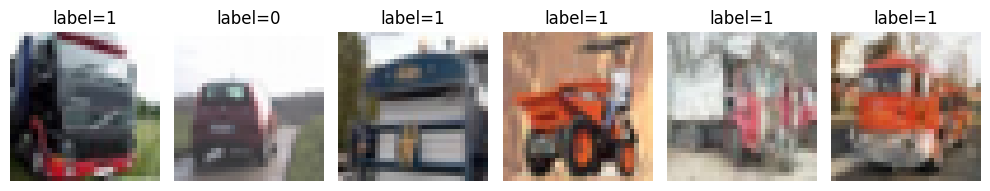

In [7]:
images, labels = next(iter(train_loader))
display_images = images.float()
if display_images.max() > 1:
    display_images = display_images / 255.0

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Unique labels in this batch:", torch.unique(labels))

plt.figure(figsize=(10, 3))
for i in range(min(6, len(display_images))):
    plt.subplot(1, 6, i + 1)
    image = display_images[i].permute(1, 2, 0).cpu().clamp(0, 1)
    plt.imshow(image)
    plt.title(f"label={labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [9]:
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def prepare_batch(images, model_type="cnn"):
    images = images.to(device).float()
    if images.max() > 1:
        images = images / 255.0

    if model_type == "resnet":
        images = F.interpolate(images, size=(224, 224), mode="bilinear", align_corners=False)
        mean = imagenet_mean.to(images.device)
        std = imagenet_std.to(images.device)
        images = (images - mean) / std

    return images


In [10]:
def evaluate_model(model, dataloader, criterion, model_type="cnn"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = prepare_batch(images, model_type=model_type)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    loss_value = running_loss / total
    accuracy_value = correct / total
    return loss_value, accuracy_value


In [11]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, model_type="cnn"):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for images, labels in train_loader:
            images = prepare_batch(images, model_type=model_type)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total
        test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, model_type=model_type)
        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"train acc: {train_accuracy:.4f} | "
            f"test loss: {test_loss:.4f} | "
            f"test acc: {test_accuracy:.4f} | "
            f"time: {epoch_time:.1f}s"
        )

    return history


In [12]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
    plt.plot(epochs, history["test_accuracy"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


## Train the baseline CNN


In [13]:
simple_cnn = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(simple_cnn.parameters(), lr=cnn_learning_rate)

cnn_history = train_model(
    model=simple_cnn,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=cnn_optimizer,
    epochs=cnn_epochs,
    model_type="cnn",
)


Epoch 1/10 | train loss: 0.5924 | train acc: 0.6806 | test loss: 0.4993 | test acc: 0.7560 | time: 4.7s
Epoch 2/10 | train loss: 0.4460 | train acc: 0.7949 | test loss: 0.4068 | test acc: 0.8250 | time: 1.9s
Epoch 3/10 | train loss: 0.3396 | train acc: 0.8563 | test loss: 0.3295 | test acc: 0.8595 | time: 1.9s
Epoch 4/10 | train loss: 0.2757 | train acc: 0.8917 | test loss: 0.2946 | test acc: 0.8800 | time: 2.0s
Epoch 5/10 | train loss: 0.2361 | train acc: 0.9052 | test loss: 0.2406 | test acc: 0.9110 | time: 2.3s
Epoch 6/10 | train loss: 0.2013 | train acc: 0.9206 | test loss: 0.2498 | test acc: 0.8995 | time: 1.9s
Epoch 7/10 | train loss: 0.1620 | train acc: 0.9379 | test loss: 0.2253 | test acc: 0.9220 | time: 2.2s
Epoch 8/10 | train loss: 0.1391 | train acc: 0.9439 | test loss: 0.2501 | test acc: 0.9125 | time: 2.1s
Epoch 9/10 | train loss: 0.1141 | train acc: 0.9551 | test loss: 0.2625 | test acc: 0.9035 | time: 2.0s
Epoch 10/10 | train loss: 0.0883 | train acc: 0.9692 | test loss

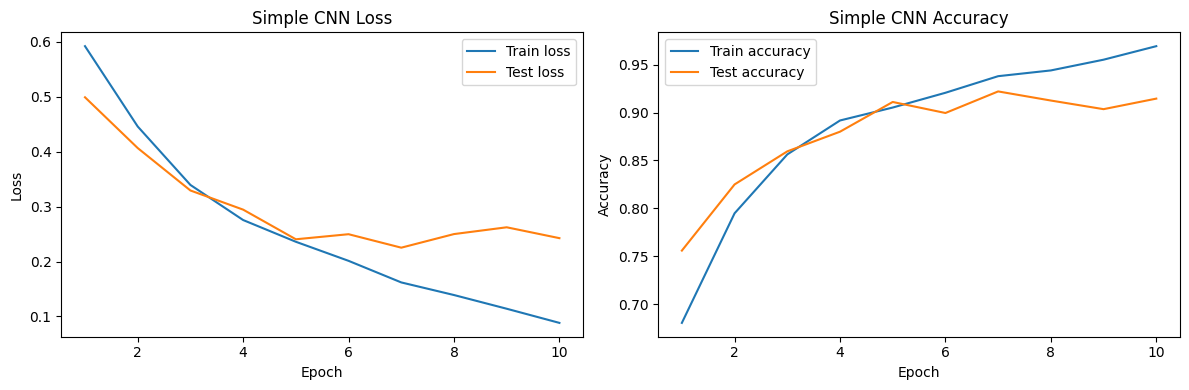

Saved baseline CNN to: saved_models/simple_cnn_car_truck.pth


In [14]:
plot_history(cnn_history, "Simple CNN")

cnn_path = os.path.join(save_dir, "simple_cnn_car_truck.pth")
torch.save(simple_cnn.state_dict(), cnn_path)
print("Saved baseline CNN to:", cnn_path)


## Train ResNet18 with transfer learning


In [15]:
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model = resnet_model.to(device)

resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=resnet_learning_rate)

resnet_history = train_model(
    model=resnet_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=resnet_criterion,
    optimizer=resnet_optimizer,
    epochs=resnet_epochs,
    model_type="resnet",
)


2.5%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/myrkur/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Epoch 1/5 | train loss: 0.1229 | train acc: 0.9534 | test loss: 0.1121 | test acc: 0.9600 | time: 143.3s
Epoch 2/5 | train loss: 0.0194 | train acc: 0.9947 | test loss: 0.0904 | test acc: 0.9700 | time: 138.4s
Epoch 3/5 | train loss: 0.0152 | train acc: 0.9948 | test loss: 0.0896 | test acc: 0.9735 | time: 138.6s
Epoch 4/5 | train loss: 0.0053 | train acc: 0.9988 | test loss: 0.1186 | test acc: 0.9650 | time: 151.2s
Epoch 5/5 | train loss: 0.0072 | train acc: 0.9977 | test loss: 0.1187 | test acc: 0.9695 | time: 150.7s


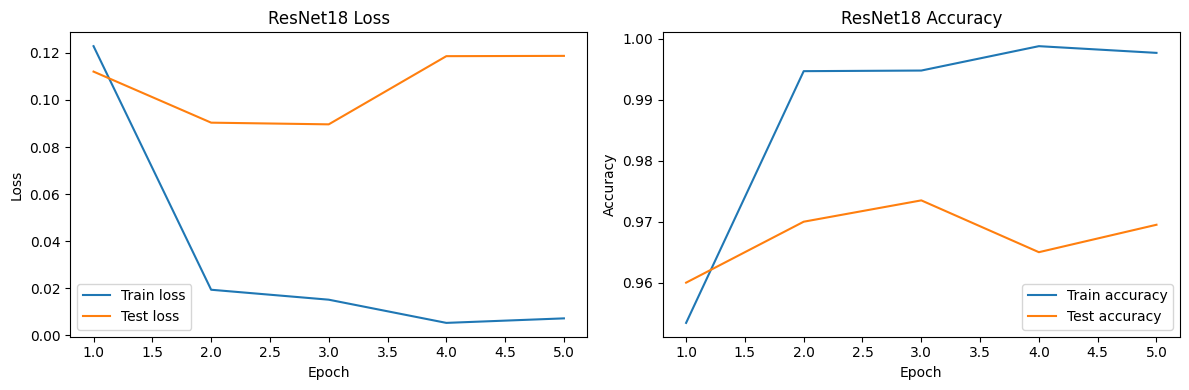

Saved ResNet18 to: saved_models/resnet18_car_truck.pth


In [16]:
plot_history(resnet_history, "ResNet18")

resnet_path = os.path.join(save_dir, "resnet18_car_truck.pth")
torch.save(resnet_model.state_dict(), resnet_path)
print("Saved ResNet18 to:", resnet_path)


## Example loading model


In [17]:
# Load the baseline CNN weights
loaded_cnn = SimpleCNN()
loaded_cnn.load_state_dict(torch.load(cnn_path, map_location="cpu"))
loaded_cnn.eval()

# Load the ResNet18 weights
loaded_resnet = resnet18(weights=None)
loaded_resnet.fc = nn.Linear(loaded_resnet.fc.in_features, 2)
loaded_resnet.load_state_dict(torch.load(resnet_path, map_location="cpu"))
loaded_resnet.eval()

print("Both saved models were loaded successfully.")


Both saved models were loaded successfully.
